## STEP 1:  Importing Libraries.  


In [143]:
 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## STEP 2: Loading the dataset.

In [82]:

# Reading the supplements dataset
sales_data = pd.read_excel("/Users/luxdevhq/Desktop/Data Science CH07/EDA/data/dirty_supplement_sales_data_2020.xlsx")


## STEP 3: Inspecting the Data. 

In [83]:

# Inspecting the top 5 rows
print(f"Top 5 rows: {display(sales_data.head())}")

# Inspecting the last 5 rows. 
print(f"Last 5 rows: {display(sales_data.tail())}")

,Date,Product Category,Product Name,Units Sold,Units Returned,Price,Discount (%),Revenue,Platform,Location
0,2020-10-07,Sleep Aids,ImmunoPro,NaN,1.0,$10.99,105.0,0.000,Instore,Los Angeles
1,2020-09-16,Vitamins,MuscleMax,NaN,-1.0,NaN,0.0,NaN,Mob App,Houston
2,2020-11-11,Immunity Boosters,Slim F@st,15.0,-1.0,15,NaN,225.000,Online,Chicago
3,2020-11-04,Energy Drinks,PowerFuel,14.0,0.0,$10.99,25.0,115.395,Online,new york
4,2020-06-03,Vitamins,SuperV!ta,NaN,NaN,$10.99,50.0,0.000,Mobile App,new york


Top 5 rows: None


,Date,Product Category,Product Name,Units Sold,Units Returned,Price,Discount (%),Revenue,Platform,Location
3095,2020-09-16,Immunity Boosters,SuperV!ta,10.0,2.0,NaN,25.0,NaN,In-Store,Chicago
3096,2020-08-12,Vitamins,DreamRest,25.0,0.0,NaN,25.0,NaN,onlien,New York
3097,2020-10-21,Immunity Boosters,SuperV!ta,NaN,-1.0,$10.99,25.0,0.0,Mobile App,Chi-Town
3098,2020-02-19,Weight Loss,SuperVita,NaN,NaN,NaN,NaN,NaN,Instore,Chicago
3099,2020-08-26,Protein,PowerFuel,NaN,0.0,15,0.0,0.0,Mobile App,Phoenix


Last 5 rows: None


In [84]:
# Getting the shape of the dataset. 
sales_data.shape

(3100, 10)

In [85]:
# Summary info about the dataset
print(sales_data.info())

print(sales_data.dtypes)

<class 'pandas.DataFrame'>
RangeIndex: 3100 entries, 0 to 3099
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              3100 non-null   str    
 1   Product Category  3100 non-null   str    
 2   Product Name      3100 non-null   str    
 3   Units Sold        1551 non-null   float64
 4   Units Returned    2495 non-null   float64
 5   Price             2457 non-null   object 
 6   Discount (%)      2651 non-null   float64
 7   Revenue           2457 non-null   float64
 8   Platform          3100 non-null   str    
 9   Location          3100 non-null   str    
dtypes: float64(4), object(1), str(5)
memory usage: 242.3+ KB
None
Date                    str
Product Category        str
Product Name            str
Units Sold          float64
Units Returned      float64
Price                object
Discount (%)        float64
Revenue             float64
Platform                str
Location             

In [86]:
# Summary statistics about the dataset. 
# i) Numerical columns. 
sales_data.describe().T # you can also use .transponse()

,count,mean,std,min,25%,50%,75%,max
Units Sold,1551.0,24.514507,14.398598,1.0,11.5,24.0,37.0,50.0
Units Returned,2495.0,0.478557,1.120023,-1.0,-1.0,0.0,1.0,2.0
Discount (%),2651.0,35.403621,35.162792,0.0,10.0,25.0,50.0,105.0
Revenue,2457.0,101.290307,159.300390,-37.5,0.0,0.0,180.0,735.0


In [87]:
# ii) Categorical columns 
sales_data.describe(include='object').T # include='object'

/var/folders/fh/dnmx2fzs5w16_qp8qtg223480000gn/T/ipykernel_1410/1396626247.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  sales_data.describe(include='object').T # include='object'


,count,unique,top,freq
Date,3100,104,2020-05-20,68
Product Category,3100,6,Protein,555
Product Name,3100,8,Slim F@st,409
Price,2457,4,12.50 USD,642
Platform,3100,6,Instore,537
Location,3100,8,L.A.,421


In [88]:
# View the columns. 
sales_data.columns

Index(['Date', 'Product Category', 'Product Name', 'Units Sold',
       'Units Returned', 'Price', 'Discount (%)', 'Revenue', 'Platform',
       'Location'],
      dtype='str')

In [89]:
# Check the null summary 
sales_data.isnull().sum()

Date                   0
Product Category       0
Product Name           0
Units Sold          1549
Units Returned       605
Price                643
Discount (%)         449
Revenue              643
Platform               0
Location               0
dtype: int64

## STEP 4: Data Cleaning
### Standardizing the column names. Why standardization matters.
- Prevent Code Errors: Python can fail if names contain hidden sapces, trailing whitespaces or special characters. 
- Simplifies merging: Joining datasets requires matching key columns(e.g dataset1 StudentID vs Student Id) p.d.merge(datset1, dataset2, on='')
- Ehances readability.   

__Common pracices in standardization.__  
i) Use lowercase letters  
ii) Replace spaces with undersscores   
iii) Do away with special characters  

In [90]:
# a) Stripping any preceding or trailing spaces. 
sales_data.columns = sales_data.columns.str.strip()

In [91]:
# b). set the column names to lowercase
sales_data.columns = sales_data.columns.str.lower()

In [92]:
# c). Remove any spaces between wordds and replace with underscores. 
sales_data.columns = sales_data.columns.str.replace(" ", "_")

In [93]:
# d). Remove special characters(replace the % in the discount column with 'percent')
sales_data = sales_data.rename(columns = {'discount_(%)':'discount_percentage'})

In [94]:
sales_data.columns

Index(['date', 'product_category', 'product_name', 'units_sold',
       'units_returned', 'price', 'discount_percentage', 'revenue', 'platform',
       'location'],
      dtype='str')

__Note:__ Instead of wrting indiviadual conversions, you can use the code below.  
```python
sales_data.columns = sales.data.columns.str.strip().str.lower().str.replace(" ", "_").str.replace('discount_(%)', 'discount_percentage', regex=False)  
```

### Standardising Data Types
__Common problems assocaited with data type.__  
- Dates stored as text
- Numbers are stored as text. 
- Currency values stored wit the symbols.  


In [95]:
sales_data.isnull().sum()

date                      0
product_category          0
product_name              0
units_sold             1549
units_returned          605
price                   643
discount_percentage     449
revenue                 643
platform                  0
location                  0
dtype: int64

In [96]:
sales_data["date"].unique()

<StringArray>
['2020-10-07', '2020-09-16', '2020-11-11', '2020-11-04', '2020-06-03',
 '2020-09-09', '2020-06-17', '2020-09-23', '2020-10-28', '2020-04-01',
 ...
 '10/06/2020', '12/08/2020', '04/11/2020', '08/01/2020', '04/03/2020',
 '29/07/2020', '11/03/2020', '28/10/2020', '23/12/2020', '08/07/2020']
Length: 104, dtype: str

In [97]:
# Converting dates to datetype 
# pd.to_datetime(df['datescolumn'], errors='coerce')

# sales_data['date'] = pd.to_datetime(sales_data["date"], errors='coerce') 
sales_data["date"] = pd.to_datetime(sales_data["date"], format='mixed', errors='coerce')


In [98]:
sales_data.dtypes

date                   datetime64[us]
product_category                  str
product_name                      str
units_sold                    float64
units_returned                float64
price                          object
discount_percentage           float64
revenue                       float64
platform                          str
location                          str
dtype: object

In [99]:
# cleaning the price column. 
sales_data["price"].unique()

array(['$10.99', nan, 15, '12.50 USD', 9.99], dtype=object)

In [100]:
# Remove the currency sign and convert to numeric format
# Dropping the currencies
sales_data["price"] = sales_data["price"].astype(str).str.replace(r'[^0-9.]', '', regex=True)

# .astype(str): Converts the entire column int text, so that the string specific manipulation method can be used.
# r[^0-9.]: The ^ inside the brackets means NOT it translates to "Find anything that is not a number (0-9) and not a decimal(.)"

# Convert the price column to numeric data type
sales_data["price"] = pd.to_numeric(sales_data["price"], errors='coerce')

In [101]:
sales_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3100 entries, 0 to 3099
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 3100 non-null   datetime64[us]
 1   product_category     3100 non-null   str           
 2   product_name         3100 non-null   str           
 3   units_sold           1551 non-null   float64       
 4   units_returned       2495 non-null   float64       
 5   price                2457 non-null   float64       
 6   discount_percentage  2651 non-null   float64       
 7   revenue              2457 non-null   float64       
 8   platform             3100 non-null   str           
 9   location             3100 non-null   str           
dtypes: datetime64[us](1), float64(5), str(4)
memory usage: 242.3 KB


_Units returned_  
There are negative entries in the units_returned column which in reality cannot be True.

In [102]:
sales_data["units_returned"] = sales_data["units_returned"].abs()

In [103]:
sales_data.head()

,date,product_category,product_name,units_sold,units_returned,price,discount_percentage,revenue,platform,location
0,2020-10-07,Sleep Aids,ImmunoPro,NaN,1.0,10.99,105.0,0.000,Instore,Los Angeles
1,2020-09-16,Vitamins,MuscleMax,NaN,1.0,NaN,0.0,NaN,Mob App,Houston
2,2020-11-11,Immunity Boosters,Slim F@st,15.0,1.0,15.00,NaN,225.000,Online,Chicago
3,2020-11-04,Energy Drinks,PowerFuel,14.0,0.0,10.99,25.0,115.395,Online,new york
4,2020-06-03,Vitamins,SuperV!ta,NaN,NaN,10.99,50.0,0.000,Mobile App,new york


### Check for duplicates and drop if there's any

In [104]:
# Check for duplicates. 
print(f"Number of duplicates in the dataset: {sales_data.duplicated().sum()}")

Number of duplicates in the dataset: 100


In [105]:
# Dropping the duplicates. 
sales_data = sales_data.drop_duplicates()

print(f"Number of duplicates after dropping:{sales_data.duplicated().sum()}")

Number of duplicates after dropping:0


### Handling Categorical columns  entries

In [106]:
sales_data["product_category"].unique()

<StringArray>
[       'Sleep Aids',          'Vitamins', 'Immunity Boosters',
     'Energy Drinks',       'Weight Loss',           'Protein']
Length: 6, dtype: str

In [107]:
# Create a list. 
categorical_cols = sales_data.select_dtypes(include='str').columns.to_list()

print(categorical_cols)  

for col in categorical_cols:
    print("="*70)
    print(f"Unique categories in '{col}'")
    print(sales_data[col].unique())

['product_category', 'product_name', 'platform', 'location']
Unique categories in 'product_category'
<StringArray>
[       'Sleep Aids',          'Vitamins', 'Immunity Boosters',
     'Energy Drinks',       'Weight Loss',           'Protein']
Length: 6, dtype: str
Unique categories in 'product_name'
<StringArray>
['ImmunoPro', 'MuscleMax', 'Slim F@st', 'PowerFuel', 'SuperV!ta', 'SuperVita',
 'DreamRest',  'SlimFast']
Length: 8, dtype: str
Unique categories in 'platform'
<StringArray>
['Instore', 'Mob App', 'Online', 'Mobile App', 'In-Store', 'onlien']
Length: 6, dtype: str
Unique categories in 'location'
<StringArray>
['Los Angeles',     'Houston',     'Chicago',    'new york',     'Phoenix',
    'New York',    'Chi-Town',        'L.A.']
Length: 8, dtype: str


__i) Product Name__

In [108]:
sales_data["product_name"] = sales_data["product_name"].replace({'Slim F@st': 'SlimFast',
                                                                 'SuperV!ta': 'SuperVita'})

In [109]:
sales_data["product_name"].unique()

<StringArray>
['ImmunoPro', 'MuscleMax', 'SlimFast', 'PowerFuel', 'SuperVita', 'DreamRest']
Length: 6, dtype: str

__ii). Platform__  
Clean and unify the platform column. categories i.e 'In-Store' Should be 'Instore', 'onlien' Should be 'Online', 'Mob App' should be 'Mobile App'

In [110]:
sales_data["platform"] = sales_data["platform"].replace({'In-Store': 'Instore',
                                                         'Mob App': 'Mobile App',
                                                         'onlien' : 'Online'})

In [111]:
sales_data["platform"].unique()

<StringArray>
['Instore', 'Mobile App', 'Online']
Length: 3, dtype: str

__iii). Location__  
Clean and unify the location column categories i.e 'L.A' should be 'Los Angeles', 'Chi-Town' should be 'Chicago', 'new york' should be 'New York'

In [112]:
sales_data["location"] = sales_data["location"].replace({"Chi-Town": "Chicago",
                                                         "new york" : "New York",
                                                         "L.A."  : "Los Angeles"})

In [113]:
sales_data["location"].unique()

<StringArray>
['Los Angeles', 'Houston', 'Chicago', 'New York', 'Phoenix']
Length: 5, dtype: str

### Handling Missing Values.  
- There's no single correct method, it depends on the column and business context. Dropping/Filling should be your last resort after every possible means has failed.  
#### Step 1: Try and calculate from the other columns where possible.  
_i). Revenue_  
Revenue = ((1-%Discount/100) * Price) * Units Sold  

${Revenue} = \left(\left(1 - \frac{\%Discount}{100}\right) \times \text{Price}\right) \times \text{Units Sold}$

_ii). Price_  
${Price}=\frac{\text{Revenue}}{\left(1-\frac{\%Discount}{100}\right)\times \text{Units\ Sold}}$  

_iii). Units Sold_  
${Units\ Sold}=\frac{\text{Revenue}}{\left(1-\frac{\%Discount}{100}\right)\times \text{Price}}$  

_iv) Discount Perecentage_. 

$(\%Discount = 100 \times \left(1 - \frac{\text{Revenue}}{\text{Price} \times \text{Units Sold}}\right)$



In [114]:
sales_data.isnull().sum()

date                      0
product_category          0
product_name              0
units_sold             1492
units_returned          587
price                   613
discount_percentage     434
revenue                 613
platform                  0
location                  0
dtype: int64

In [115]:
import numpy as np  

def calculate_financials(row):
    # 'row' represents a singler horizontal record of the data from the dataframe/dataset
    u, p, d, r = row['units_sold'], row['price'], row['discount_percentage'], row['revenue']

    # 1. Reset abnormal discounts to try and recalculate them
    # If the discount exists but unrealistc (over 100% or below 0%), we wipe it out
    if pd.notna(d) and (d > 100 or d < 0):
        d = np.nan # Reset them to be null values.  

    # 2. Formulas to fill the nulls
    # Calculate REVENUE
    if pd.isna(r) and pd.notna(u) and pd.notna(p) and pd.notna(d):
        r = (1-d/100) * p  * u

    # Calculate UNITS SOLD
    elif pd.isna(u) and pd.notna(r) and pd.notna(p) and pd.notna(d):
        denom = (1 - d/100) * p
        u = r/denom if denom  != 0 else (0.0 if r == 0 else np.nan) 

    # calculate PRICE
    elif pd.isna(p) and pd.notna(r) and pd.notna(u) and pd.notna(d):
        denom = (1- d/100) * u 
        p = r/denom if denom != 0 else np.nan  
    # calculate DICOUNT
    elif pd.isna(d) and pd.notna(r) and pd.notna(p) and pd.notna(u):
        # Gross Sales
        u_p = u * p

        # Discount
        d=100 * (1 - r/u_p) if u_p !=0 else np.nan

    # 3. Update the row with calculated values(Or Nulls where calculation wasn't possible)
    row['units_sold'], row['price'], row['discount_percentage'], row['revenue'] = u, p, d, r

    # Return the fully modified row back to the pandas processing loop
    return row

In [116]:
# Apply the transformation function
sales_data = sales_data.apply(calculate_financials, axis=1)

In [117]:
sales_data.isnull().sum()

date                     0
product_category         0
product_name             0
units_sold             639
units_returned         587
price                  613
discount_percentage    539
revenue                613
platform                 0
location                 0
dtype: int64

_Handling the remaining nulls_

In [127]:
nulls = (sales_data.isnull().sum()/len(sales_data)) * 100

print(nulls)

date                    0.000000
product_category        0.000000
product_name            0.000000
units_sold              0.000000
units_returned         19.566667
price                  20.433333
discount_percentage    17.966667
revenue                20.433333
platform                0.000000
location                0.000000
dtype: float64


In [126]:
median_units_sold = sales_data["units_sold"].median()

print(median_units_sold)

sales_data["units_sold"] = sales_data["units_sold"].fillna(median_units_sold)

11.0


In [129]:
numerical_cols = sales_data.select_dtypes(include=["float", "int"]).columns.to_list()
print(numerical_cols)

for column in numerical_cols:
    median = sales_data[column].median()
    sales_data[column] = sales_data[column].fillna(median)

sales_data.isnull().sum()

['units_sold', 'units_returned', 'price', 'discount_percentage', 'revenue']


date                   0
product_category       0
product_name           0
units_sold             0
units_returned         0
price                  0
discount_percentage    0
revenue                0
platform               0
location               0
dtype: int64

### Final Basic checks


In [130]:
sales_data.head()

,date,product_category,product_name,units_sold,units_returned,price,discount_percentage,revenue,platform,location
0,2020-10-07,Sleep Aids,ImmunoPro,11.0,1.0,10.99,20.0,0.000,Instore,Los Angeles
1,2020-09-16,Vitamins,MuscleMax,11.0,1.0,12.50,0.0,0.000,Mobile App,Houston
2,2020-11-11,Immunity Boosters,SlimFast,15.0,1.0,15.00,0.0,225.000,Online,Chicago
3,2020-11-04,Energy Drinks,PowerFuel,14.0,0.0,10.99,25.0,115.395,Online,New York
4,2020-06-03,Vitamins,SuperVita,0.0,1.0,10.99,50.0,0.000,Mobile App,New York


In [131]:
sales_data.describe().T

,count,mean,min,25%,50%,75%,max,std
date,3000,2020-06-26 04:37:26.400000,2020-01-01 00:00:00,2020-03-25 00:00:00,2020-06-24 00:00:00,2020-09-23 00:00:00,2020-12-23 00:00:00,NaN
units_sold,3000.0,14.698333,0.0,0.0,11.0,24.0,50.0,14.759944
units_returned,3000.0,0.991333,0.0,1.0,1.0,1.0,2.0,0.633029
price,3000.0,12.194073,9.99,10.99,12.5,12.5,15.0,1.673396
discount_percentage,3000.0,24.51,0.0,10.0,20.0,25.0,105.0,24.867302
revenue,3000.0,80.869101,-37.5,0.0,0.0,112.5,735.0,148.226501


In [132]:
sales_data.dtypes

date                   datetime64[us]
product_category                  str
product_name                      str
units_sold                    float64
units_returned                float64
price                         float64
discount_percentage           float64
revenue                       float64
platform                          str
location                          str
dtype: object

## Final Step: Save the cleaned Dataset

In [133]:
sales_data.to_csv("../data/processed/clean_data_morning.csv", index=False)

# EDA(Exploratory Data Analysis). 
### Business questions. 
1. Which Product categories generate the highest revenue weekly?


/var/folders/fh/dnmx2fzs5w16_qp8qtg223480000gn/T/ipykernel_1410/3199905377.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(weekly_category_revenue, x="revenue", y="product_category", palette="colorblind")


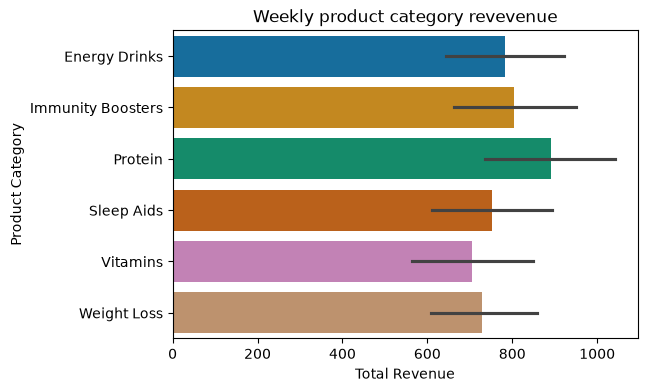

In [148]:
# Create a week column.  
sales_data["week"] = sales_data["date"].dt.to_period("W").apply(lambda x: x.start_time)

# Weekly revenue by product category
weekly_category_revenue = (sales_data.groupby(["week", "product_category"])["revenue"].sum().reset_index())

weekly_category_revenue 

plt.figure(figsize=(6,4))
sns.barplot(weekly_category_revenue, x="revenue", y="product_category", palette="colorblind")
plt.title("Weekly product category revevenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product Category")
plt.show()

### TakeAway Practice tasks. 
Explore, visualize and give findings on the following business questions.  
1. Univariate Analysis  
    - What is the most common product category sold?
    - What is the most common sales platform?
    - What is the distribution of product prices?
    - What is the distribution of discount percentages?
    - Which products appear most frequently in the dataset? 
2. Bivariate Analysis. 
    - Which product category generates the highest total revenue?
    - Which platform sells the most units?
    - Which location generates the highest revenue?
    - Does a higher discount lead to more units sold?
    - Do higher prices reduce the number of units sold?
    - Are returned units associated with lower revenue? 

3. Multivariate Analysis.  
    - Which product category performs best on each platform?
    - Which location performs best for each platform?
    - Which category-platform combination generates the highest revenue?
    - Which location-platform combination sells the most units?
    - How does discount percentage affect revenue across different product categories?
    - How does price affect units sold across different platforms?
    - Which products perform best when considering revenue, units sold, platform, and location together?

In [ ]:
# Profit 
Profit = Sales - Cost 

# Sales. 
Sales = Cost + Profit 

# Cost 
Cost = Sales - Profit